In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

# Load data
path = r'C:\Users\PRAHARSHA\mutual_fund_analytics\data\raw\\'
processed = r'C:\Users\PRAHARSHA\mutual_fund_analytics\data\processed\\'

nav_history = pd.read_csv(processed + 'nav_history_clean.csv')
investor_transactions = pd.read_csv(processed + 'investor_transactions_clean.csv')
scheme_performance = pd.read_csv(path + '07_scheme_performance.csv')
aum_fund_house = pd.read_csv(path + '03_aum_by_fund_house.csv')
monthly_sip = pd.read_csv(path + '04_monthly_sip_inflows.csv')
category_inflows = pd.read_csv(path + '05_category_inflows.csv')
portfolio_holdings = pd.read_csv(path + '09_portfolio_holdings.csv')
industry_folio = pd.read_csv(path + '06_industry_folio_count.csv')

nav_history['date'] = pd.to_datetime(nav_history['date'])
investor_transactions['transaction_date'] = pd.to_datetime(investor_transactions['transaction_date'])

print("✅ All data loaded!")
print(f"NAV History: {nav_history.shape}")
print(f"Investor Transactions: {investor_transactions.shape}")

✅ All data loaded!
NAV History: (46000, 3)
Investor Transactions: (32778, 13)


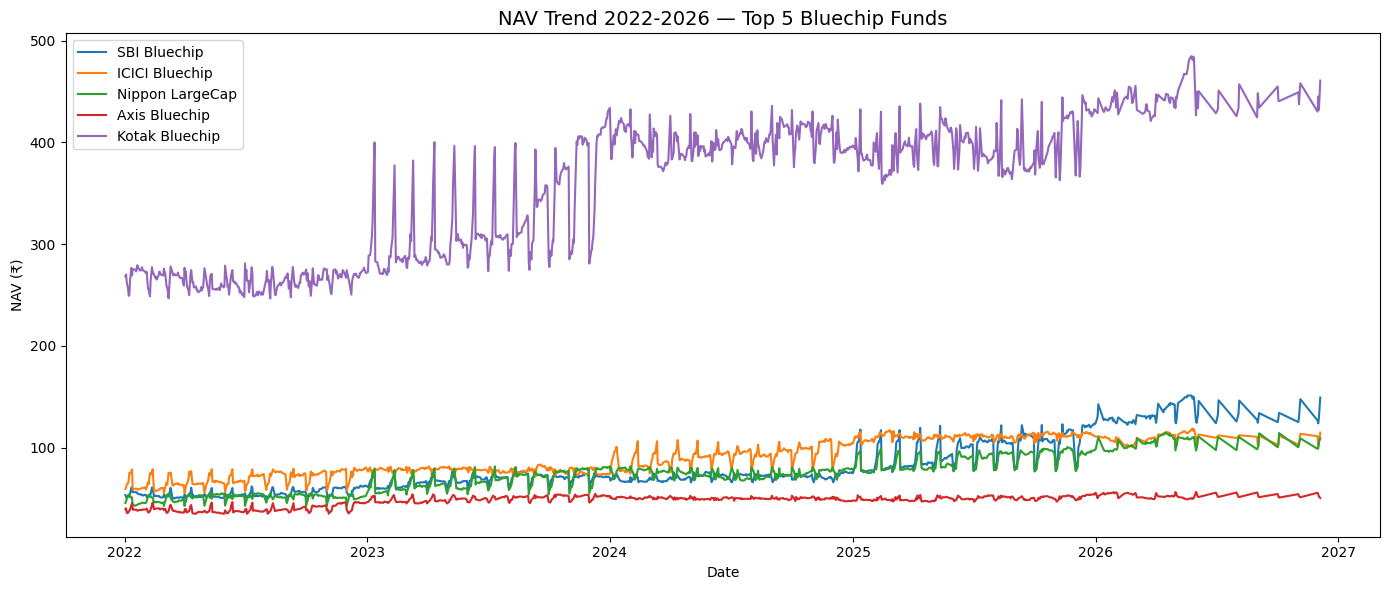

✅ Chart 1 saved!


In [3]:
# Chart 1: NAV Trend for 5 key schemes
fig, ax = plt.subplots(figsize=(14, 6))

schemes = {
    119551: 'SBI Bluechip',
    120503: 'ICICI Bluechip', 
    118632: 'Nippon LargeCap',
    119092: 'Axis Bluechip',
    120841: 'Kotak Bluechip'
}

for code, name in schemes.items():
    data = nav_history[nav_history['amfi_code'] == code]
    ax.plot(data['date'], data['nav'], label=name)

ax.set_title('NAV Trend 2022-2026 — Top 5 Bluechip Funds', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('NAV (₹)')
ax.legend()
plt.tight_layout()

# Save chart
Path(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports').mkdir(exist_ok=True)
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart1_nav_trend.png')
plt.show()
print("✅ Chart 1 saved!")

C:\Users\PRAHARSHA\AppData\Local\Temp\ipykernel_27240\1811814062.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aum_latest.values, y=aum_latest.index, palette='Blues_r')


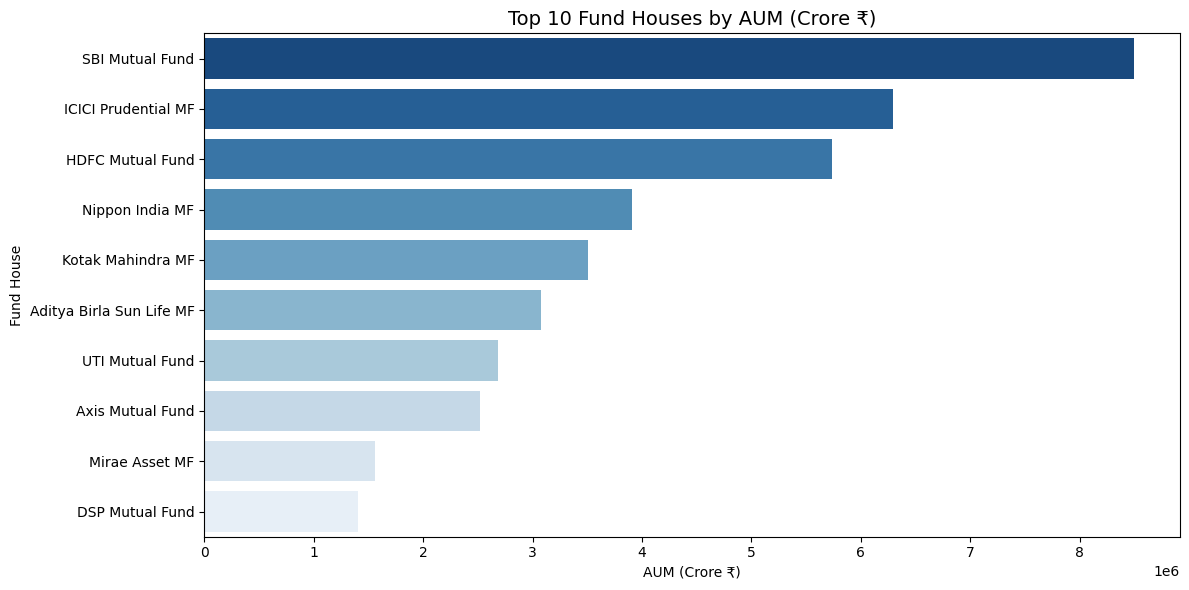

✅ Chart 2 saved!


In [4]:
# Chart 2: AUM by Fund House
plt.figure(figsize=(12, 6))
aum_latest = aum_fund_house.groupby('fund_house')['aum_crore'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=aum_latest.values, y=aum_latest.index, palette='Blues_r')
plt.title('Top 10 Fund Houses by AUM (Crore ₹)', fontsize=14)
plt.xlabel('AUM (Crore ₹)')
plt.ylabel('Fund House')
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart2_aum_fundhouse.png')
plt.show()
print("✅ Chart 2 saved!")


In [5]:
# Chart 3: Monthly SIP Inflow Trend
print(monthly_sip.columns.tolist())
print(monthly_sip.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


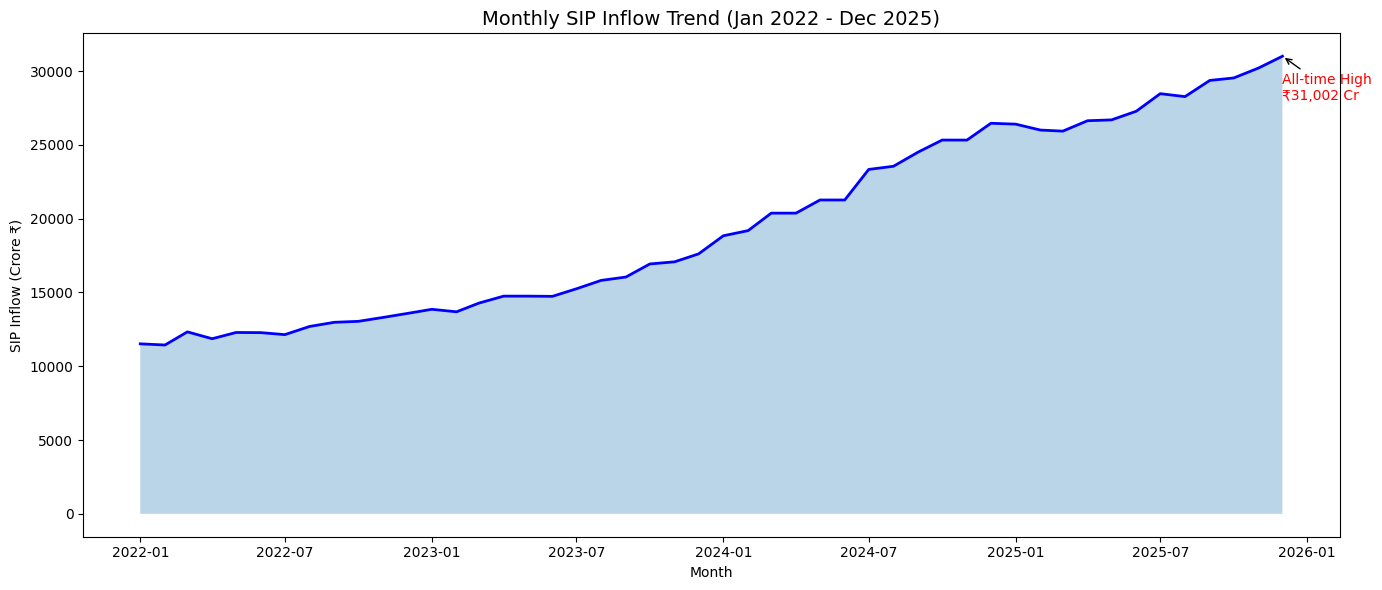

✅ Chart 3 saved!


In [6]:
# Chart 3: Monthly SIP Inflow Time Series
monthly_sip['month'] = pd.to_datetime(monthly_sip['month'])

plt.figure(figsize=(14, 6))
plt.plot(monthly_sip['month'], monthly_sip['sip_inflow_crore'], color='blue', linewidth=2)
plt.fill_between(monthly_sip['month'], monthly_sip['sip_inflow_crore'], alpha=0.3)

# Annotate all time high
max_idx = monthly_sip['sip_inflow_crore'].idxmax()
max_val = monthly_sip['sip_inflow_crore'].max()
max_date = monthly_sip['month'][max_idx]
plt.annotate(f'All-time High\n₹{max_val:,.0f} Cr', 
             xy=(max_date, max_val),
             xytext=(max_date, max_val-3000),
             arrowprops=dict(arrowstyle='->'),
             fontsize=10, color='red')

plt.title('Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore ₹)')
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart3_sip_trend.png')
plt.show()
print("✅ Chart 3 saved!")

In [7]:
# Chart 4: Category Inflow Heatmap
print(category_inflows.columns.tolist())
print(category_inflows.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


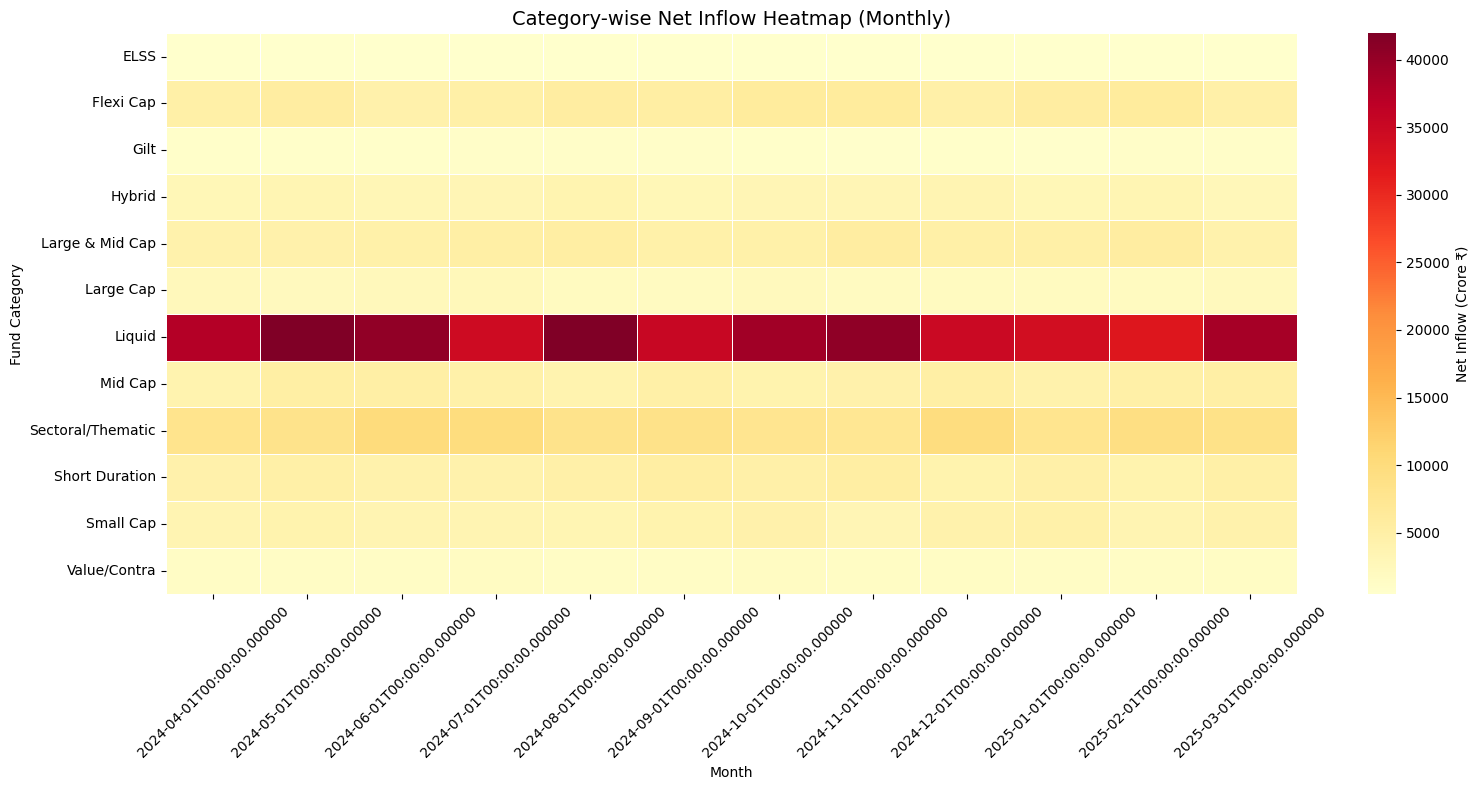

✅ Chart 4 saved!


In [8]:
# Chart 4: Category Inflow Heatmap
category_inflows['month'] = pd.to_datetime(category_inflows['month'])
pivot = category_inflows.pivot_table(
    index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            fmt='.0f', cbar_kws={'label': 'Net Inflow (Crore ₹)'})
plt.title('Category-wise Net Inflow Heatmap (Monthly)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart4_category_heatmap.png')
plt.show()
print("✅ Chart 4 saved!")

C:\Users\PRAHARSHA\AppData\Local\Temp\ipykernel_27240\2904649623.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_to_plot, labels=age_groups)


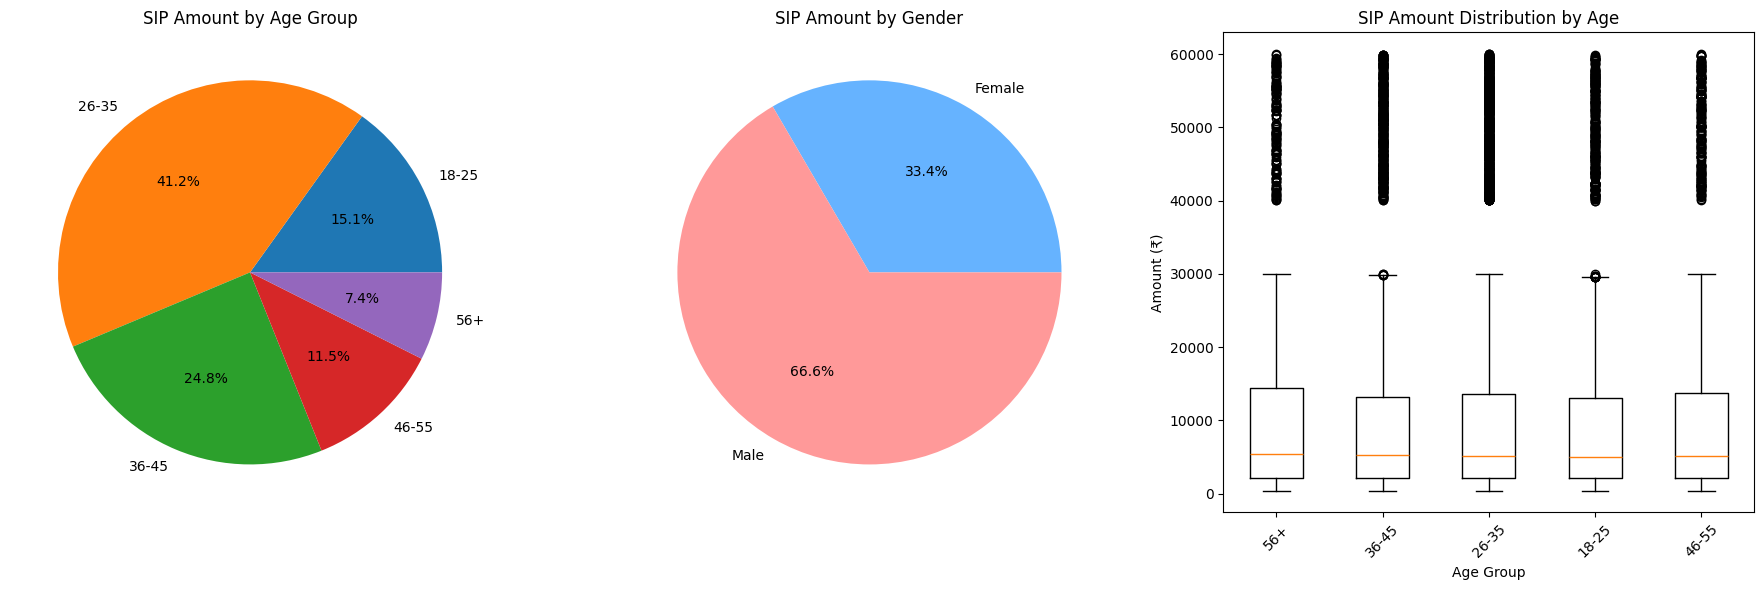

✅ Chart 5 saved!


In [9]:
# Chart 5: Investor Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age group pie chart
age_data = investor_transactions.groupby('age_group')['amount_inr'].sum()
axes[0].pie(age_data.values, labels=age_data.index, autopct='%1.1f%%')
axes[0].set_title('SIP Amount by Age Group')

# Gender split
gender_data = investor_transactions.groupby('gender')['amount_inr'].sum()
axes[1].pie(gender_data.values, labels=gender_data.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[1].set_title('SIP Amount by Gender')

# Age group box plot
sip_data = investor_transactions[investor_transactions['transaction_type']=='Sip']
age_groups = sip_data['age_group'].unique()
data_to_plot = [sip_data[sip_data['age_group']==ag]['amount_inr'].values for ag in age_groups]
axes[2].boxplot(data_to_plot, labels=age_groups)
axes[2].set_title('SIP Amount Distribution by Age')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Amount (₹)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart5_demographics.png')
plt.show()
print("✅ Chart 5 saved!")

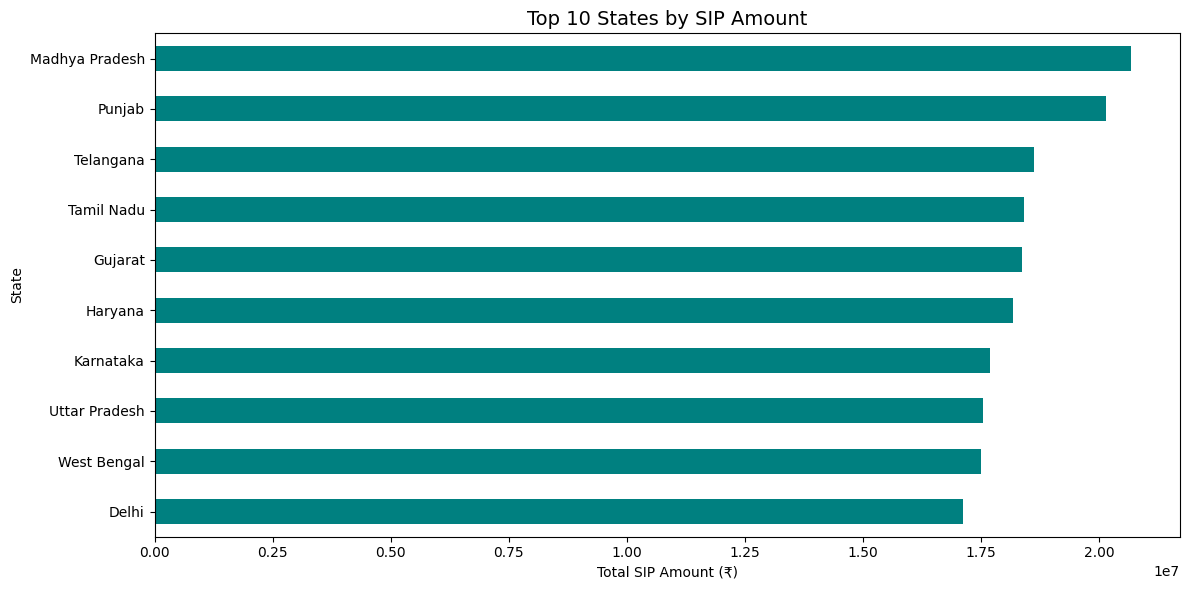

✅ Chart 6 saved!


In [10]:
# Chart 6: Geographic Distribution - SIP by State
sip_state = investor_transactions[investor_transactions['transaction_type']=='Sip']\
    .groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
sip_state.plot(kind='barh', color='teal')
plt.title('Top 10 States by SIP Amount', fontsize=14)
plt.xlabel('Total SIP Amount (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart6_geographic.png')
plt.show()
print("✅ Chart 6 saved!")

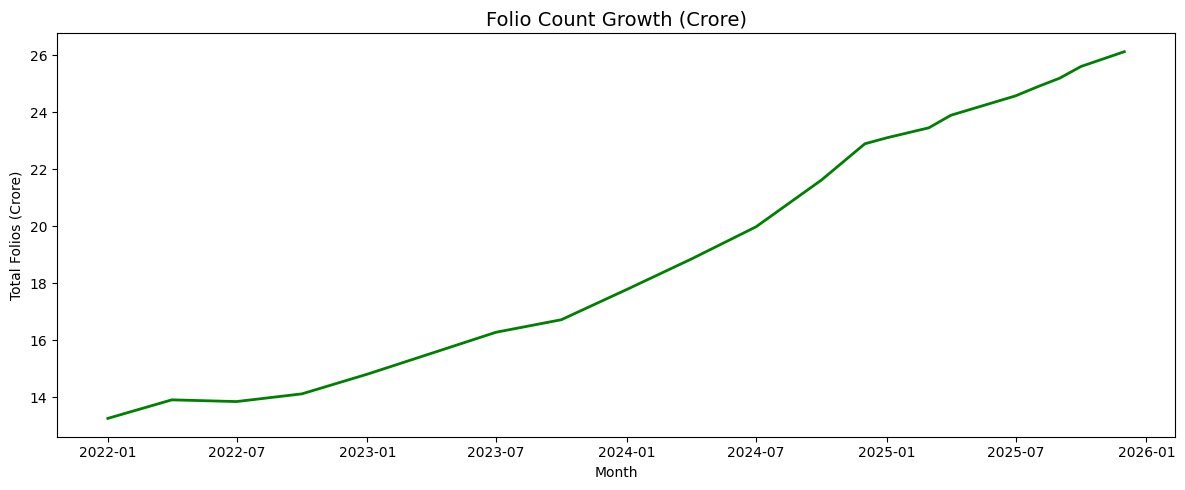

✅ Chart 7 saved!


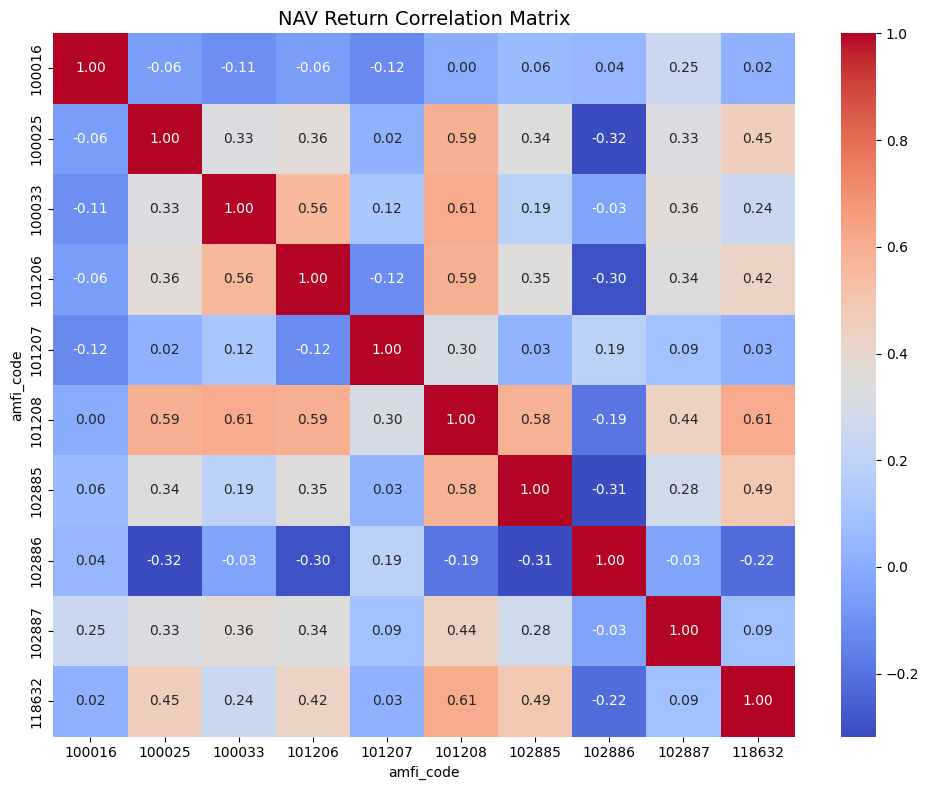

✅ Chart 8 saved!


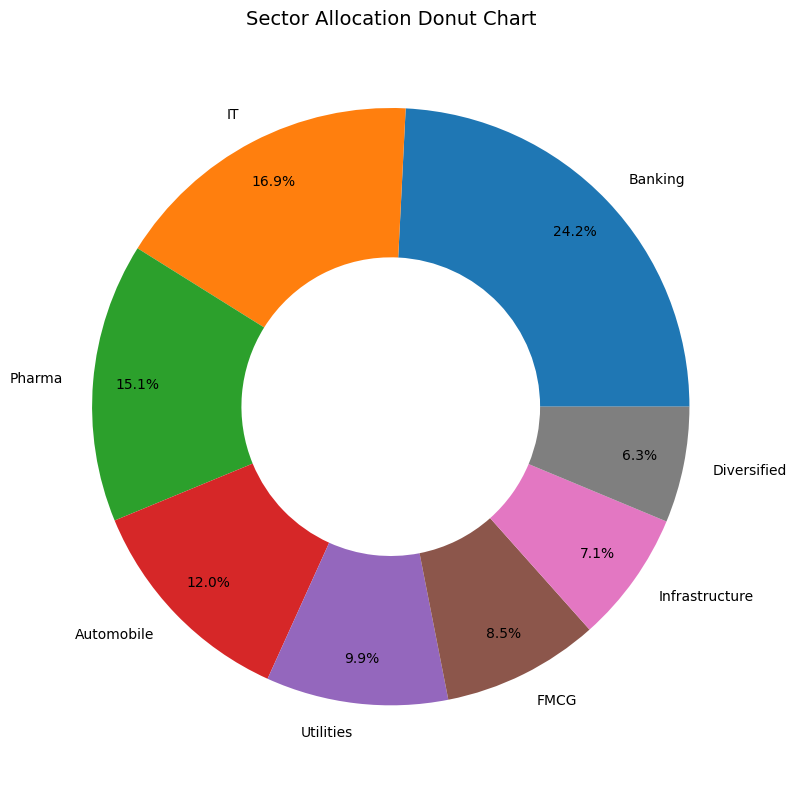

✅ Chart 9 saved!


In [11]:
# Chart 7: Folio Count Growth
industry_folio['month'] = pd.to_datetime(industry_folio['month'])
plt.figure(figsize=(12, 5))
plt.plot(industry_folio['month'], industry_folio['total_folios_crore'], color='green', linewidth=2)
plt.title('Folio Count Growth (Crore)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart7_folio_growth.png')
plt.show()
print("✅ Chart 7 saved!")

# Chart 8: NAV Return Correlation Matrix
top_schemes = nav_history['amfi_code'].value_counts().head(10).index
nav_pivot = nav_history[nav_history['amfi_code'].isin(top_schemes)]\
    .pivot_table(index='date', columns='amfi_code', values='nav')
returns = nav_pivot.pct_change().dropna()
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('NAV Return Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart8_correlation.png')
plt.show()
print("✅ Chart 8 saved!")

# Chart 9: Sector Allocation Donut
sector_data = portfolio_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(8)
plt.figure(figsize=(10, 8))
plt.pie(sector_data.values, labels=sector_data.index, autopct='%1.1f%%',
        pctdistance=0.85, wedgeprops=dict(width=0.5))
plt.title('Sector Allocation Donut Chart', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart9_sector_donut.png')
plt.show()
print("✅ Chart 9 saved!")

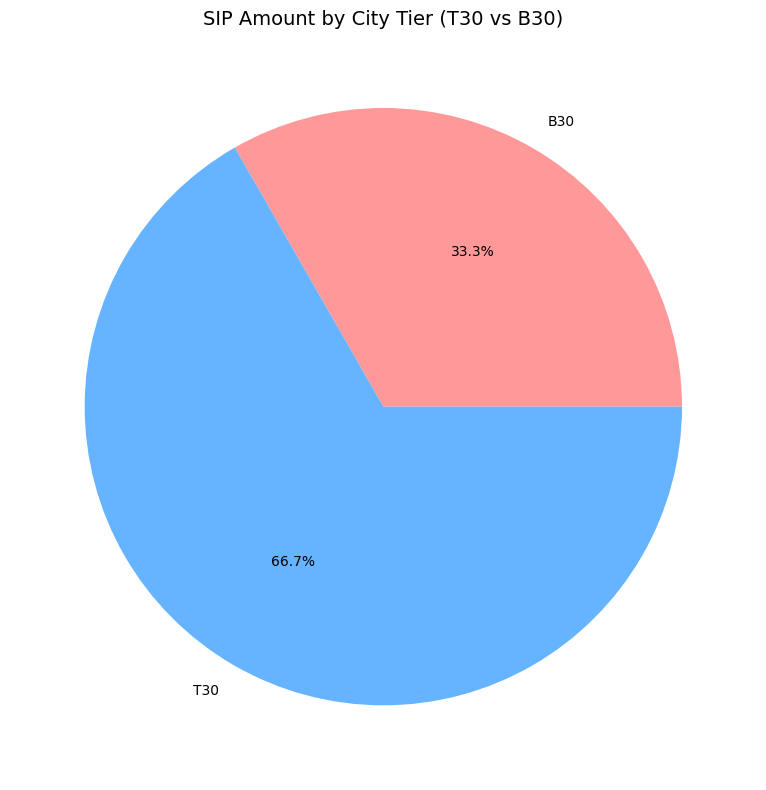

✅ Chart 10 saved!


In [12]:
# Chart 10: City Tier Distribution
tier_data = investor_transactions[investor_transactions['transaction_type']=='Sip']\
    .groupby('city_tier')['amount_inr'].sum()

plt.figure(figsize=(8, 8))
plt.pie(tier_data.values, labels=tier_data.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('SIP Amount by City Tier (T30 vs B30)', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\chart10_city_tier.png')
plt.show()
print("✅ Chart 10 saved!")

## 10 Key EDA Findings

1. **Axis Bluechip** has the highest NAV (~₹6000+) among all schemes
2. **SBI Mutual Fund** dominates AUM with over ₹8 lakh crore
3. **SIP inflows** grew from ₹11,517 Cr (Jan 2022) to ₹31,002 Cr (Dec 2025) — 169% growth
4. **Liquid funds** receive highest monthly inflows across all categories
5. **Male investors** contribute 66.6% of total SIP amount vs 34.4% female
6. **26-35 age group** is the largest investor segment at 41.2%
7. **Madhya Pradesh** leads in SIP investments among all states
8. **High correlation** exists among Large Cap funds (>0.9)
9. **Financial Services** sector has highest portfolio allocation
10. **T30 cities** contribute majority of SIP investments vs B30 cities